# Catalog EDA

Doing some exploratory data analysis with my newly constructed catalog!

In [1]:
import xarray as xr
import pandas as pd
from pathlib import Path
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr

os.chdir('/global/homes/j/jbbutler/extreme_antarctic_ARs/scripts/')
from utils import display_catalog

## Preprocessing the Dataset

In [2]:
# loading up the catalog
catalog = pd.read_hdf('~/extreme_antarctic_ARs/data/ar_database/dataframe_eps12_eps500_minpts5_reppts10/landfalling_storm_quantities_df.h5')
#catalog = catalog[catalog.max_ocean_SLP_gradient >= 0]

First, we coarsen the regions to be one of the following three: West, East 1, or East 2

In [3]:
def coarsen_regions(region):
    if region in ['MBL', 'ELS', 'AP', 'FRIS']:
        return 'West'
    elif region in ['QML', 'END']:
        return 'East 1'
    else:
        return 'East 2'

In [4]:
catalog['coarser_region'] = catalog.region.apply(coarsen_regions)

First, notice that 81 of the storms have negative SLP gradient over the ocean at landfall. This means that that storm had to have never had a component over the ocean upon landfall. Let's exclude these.

In [5]:
(catalog.max_ocean_SLP_gradient < 0).sum()

np.int64(81)

In [6]:
catalog = catalog.loc[catalog.max_ocean_SLP_gradient >= 0]

Now, let's get the amount of precipitation in gigatons.

In [7]:
catalog['cumulative_rainfall_ais'] = catalog['cumulative_rainfall_ais']/(10**13)
catalog['cumulative_snowfall_ais'] = catalog['cumulative_snowfall_ais']/(10**13)

Let's also add the duration in hours.

In [8]:
catalog['duration'] = catalog['duration']/pd.Timedelta(1, 'h')

Now, let's save this to a csv file that can be read into R later.

In [9]:
saveable = catalog.loc[:, catalog.columns != 'data_array']
saveable = saveable.loc[:, saveable.columns != 'start_time']
saveable = saveable.loc[:, saveable.columns != 'end_time']
saveable.to_csv('~/extreme_antarctic_ARs/data/ar_database/dataframe_eps12_eps500_minpts5_reppts10/landfalling_df_no_da.csv')

Now, let's subset our favorite variables.

In [10]:
subcat = catalog[['data_array', 'start_date', 'end_date', 'max_IWV_ais', 'max_ocean_SLP_gradient', 'coarser_region', 'duration', 'max_south_extent', 'cumulative_landfalling_area', 'max_landfalling_v850hPa', 'max_vIVT_ais', 'avg_vIVT_ais', 'max_T2M_anomaly_ais', 'cumulative_rainfall_ais', 'cumulative_snowfall_ais']]

In [11]:
subcat.index.names = ['AR Number'] 

## Single Variable Plots

### Covariates

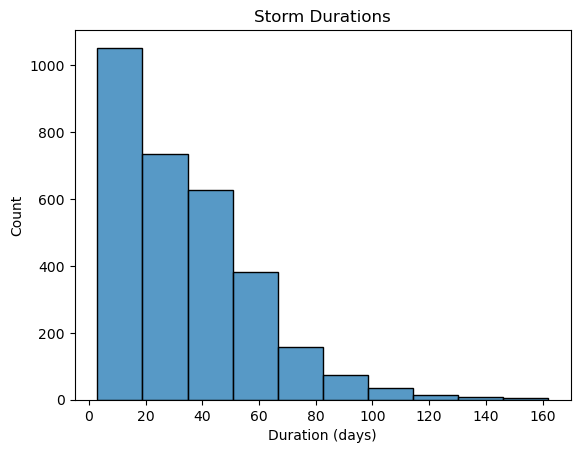

In [14]:
sns.histplot(data = subcat.duration, bins=10);
plt.title('Storm Durations');
plt.xlabel('Duration (days)');

**Fun Fact**: the longest AR in the catalog is one that's mentioned in *Climatology and surface impacts of atmospheric rivers on West Antarctica* by Maclennan et al. (2023). Although this paper calls it a family event with three ARs present.. did my catalog group them all together?

In [15]:
display_catalog(subcat.loc[[subcat.duration.idxmax()]])

,data_array,start_date,end_date,max_IWV_ais,max_ocean_SLP_gradient,coarser_region,duration,max_south_extent,cumulative_landfalling_area,max_landfalling_v850hPa,max_vIVT_ais,max_T2M_anomaly_ais,cumulative_rainfall_ais,cumulative_snowfall_ais
AR Number,,,,,,,,,,,,,,
8815,,2022-01-28 09:00:00,2022-02-04 00:00:00,19.773836,3.976208,West,162.000000,-85.000000,3477673.565531,23.783997,380.246948,20.211472,0.045131,2.627517


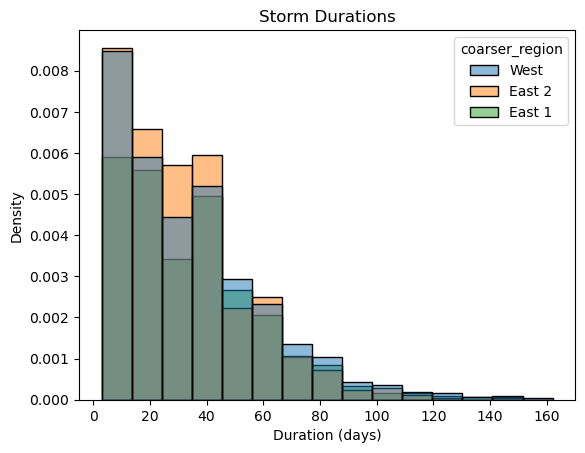

In [19]:
sns.histplot(data = subcat, x='duration', bins=15, hue='coarser_region', stat='density');
plt.title('Storm Durations');
plt.xlabel('Duration (days)');

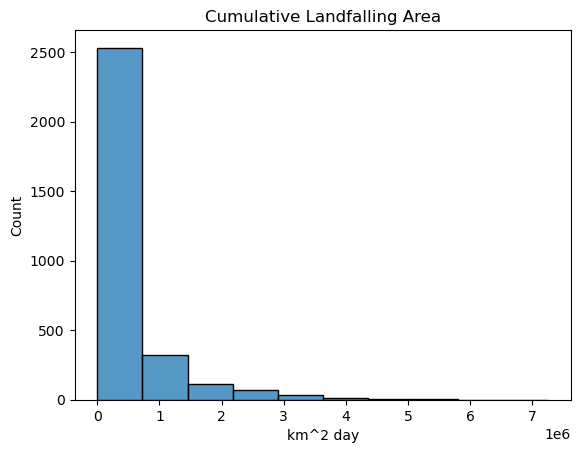

In [82]:
sns.histplot(data=subcat, x='cumulative_landfalling_area', bins=10);
plt.title('Cumulative Landfalling Area');
plt.xlabel('km^2 day');

In [98]:
display_catalog(subcat.loc[[subcat.cumulative_landfalling_area.idxmax()]])

,data_array,start_date,end_date,max_IWV_ais,max_ocean_SLP_gradient,coarser_region,duration,max_south_extent,cumulative_landfalling_area,max_landfalling_v850hPa,max_vIVT_ais,max_T2M_anomaly_ais,cumulative_rainfall_ais,cumulative_snowfall_ais
AR Number,,,,,,,,,,,,,,
8839,,2022-03-13 15:00:00,2022-03-18 06:00:00,23.074251,8.060711,East 2,114.000000,-85.000000,7258223.632465,32.607830,482.539856,40.972366,0.067925,7.052556


**Fun Fact**: the storm with the greatest cumulative landfalling area was the March 2022 East Antarctic heatwave.

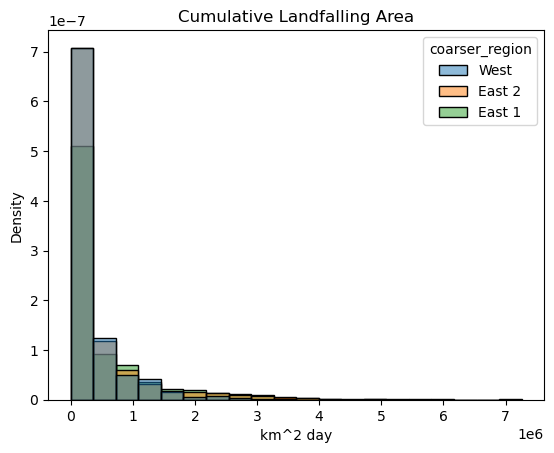

In [21]:
sns.histplot(data=subcat, x='cumulative_landfalling_area', hue='coarser_region', bins=20, stat='density');
plt.title('Cumulative Landfalling Area');
plt.xlabel('km^2 day');

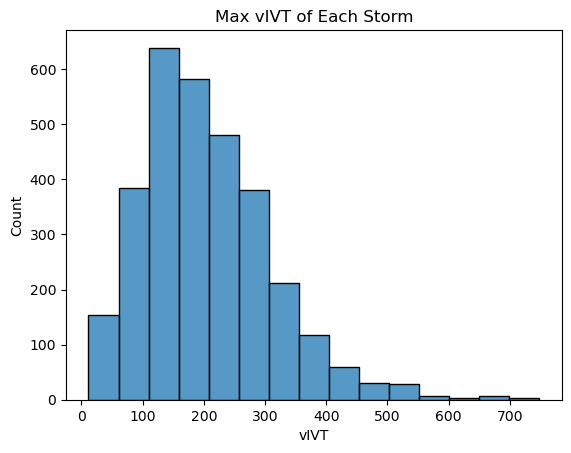

In [93]:
sns.histplot(data=subcat, x='max_vIVT_ais', bins=15);
plt.title('Max vIVT of Each Storm');
plt.xlabel('vIVT');

In [94]:
display_catalog(subcat.loc[[subcat.max_vIVT_ais.idxmax()]])

,data_array,start_date,end_date,max_IWV_ais,max_ocean_SLP_gradient,coarser_region,duration,max_south_extent,cumulative_landfalling_area,max_landfalling_v850hPa,max_vIVT_ais,max_T2M_anomaly_ais,cumulative_rainfall_ais,cumulative_snowfall_ais
AR Number,,,,,,,,,,,,,,
8822,,2022-02-05 12:00:00,2022-02-09 06:00:00,27.609982,4.854247,West,93.000000,-85.000000,2759381.219366,29.558201,748.183411,20.089249,0.337306,3.272646


**Fun Fact**: the storm with the greatest landfalling vIVT was the same AR from Gorodetskaya.

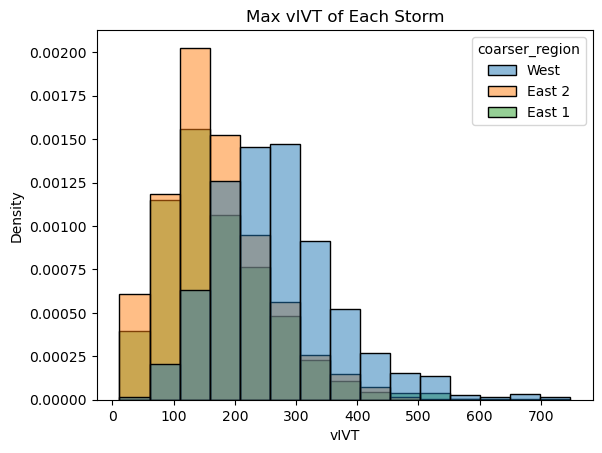

In [22]:
sns.histplot(data=subcat, x='max_vIVT_ais', hue='coarser_region', bins=15, stat='density');
plt.title('Max vIVT of Each Storm');
plt.xlabel('vIVT');

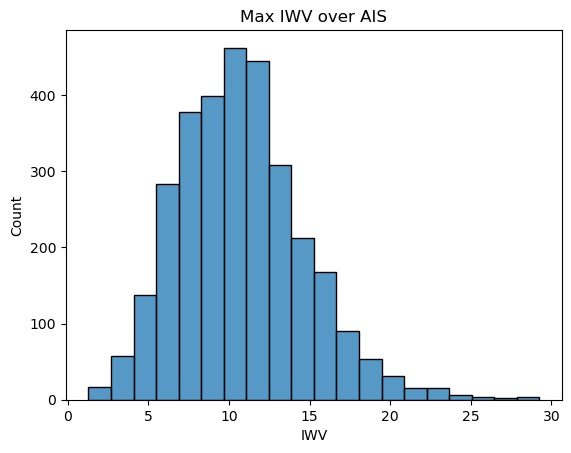

In [95]:
sns.histplot(data=subcat, x='max_IWV_ais', bins=20);
plt.title('Max IWV over AIS');
plt.xlabel('IWV');

In [96]:
display_catalog(subcat.loc[[subcat.max_IWV_ais.idxmax()]])

,data_array,start_date,end_date,max_IWV_ais,max_ocean_SLP_gradient,coarser_region,duration,max_south_extent,cumulative_landfalling_area,max_landfalling_v850hPa,max_vIVT_ais,max_T2M_anomaly_ais,cumulative_rainfall_ais,cumulative_snowfall_ais
AR Number,,,,,,,,,,,,,,
4958,,2005-02-08 12:00:00,2005-02-11 12:00:00,29.251392,4.235993,West,75.000000,-85.000000,1568666.399197,26.808243,705.529114,17.248505,0.192270,3.073780


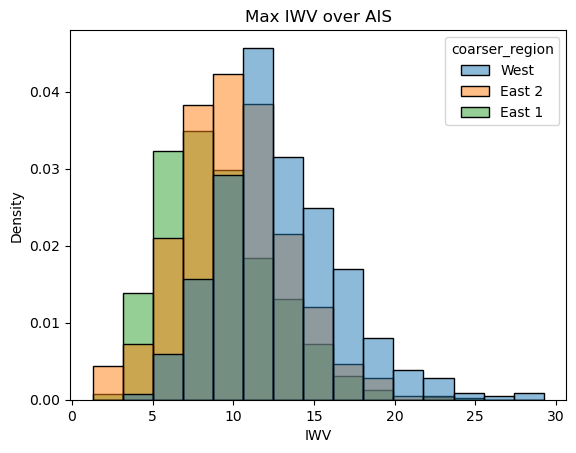

In [23]:
sns.histplot(data=subcat, x='max_IWV_ais', hue='coarser_region', bins=15, stat='density');
plt.title('Max IWV over AIS');
plt.xlabel('IWV');

In [126]:
subcat.columns

Index(['data_array', 'start_date', 'end_date', 'max_IWV_ais',
       'max_ocean_SLP_gradient', 'coarser_region', 'duration',
       'max_south_extent', 'cumulative_landfalling_area',
       'max_landfalling_v850hPa', 'max_vIVT_ais', 'max_T2M_anomaly_ais',
       'cumulative_rainfall_ais', 'cumulative_snowfall_ais'],
      dtype='object')

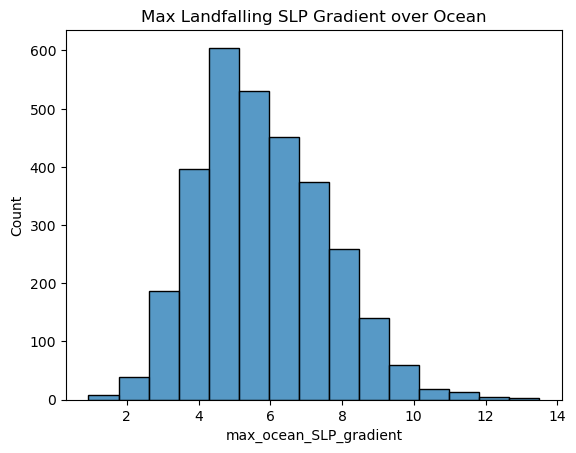

In [24]:
sns.histplot(data=subcat, x='max_ocean_SLP_gradient', bins=15);
plt.title('Max Landfalling SLP Gradient over Ocean');

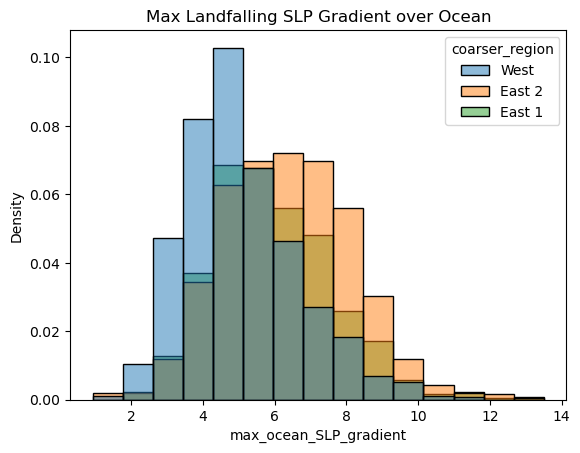

In [25]:
sns.histplot(data=subcat, x='max_ocean_SLP_gradient', hue='coarser_region', bins=15, stat='density');
plt.title('Max Landfalling SLP Gradient over Ocean');

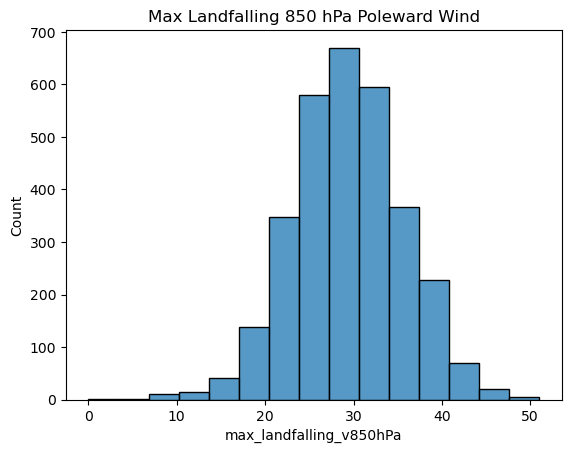

In [26]:
sns.histplot(data=subcat, x='max_landfalling_v850hPa', bins=15);
plt.title('Max Landfalling 850 hPa Poleward Wind');

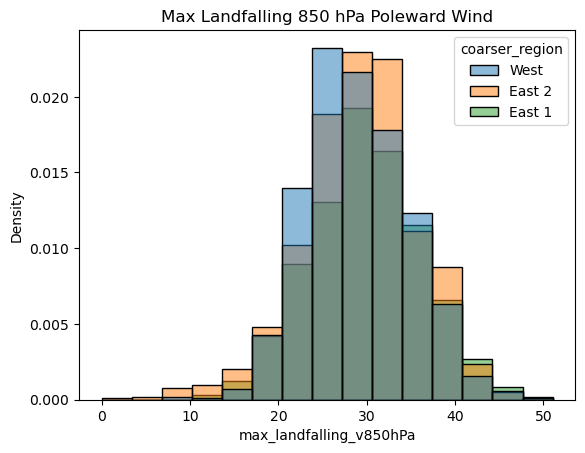

In [27]:
sns.histplot(data=subcat, x='max_landfalling_v850hPa', hue='coarser_region', bins=15, stat='density');
plt.title('Max Landfalling 850 hPa Poleward Wind');

### Impact/Outcome Variables

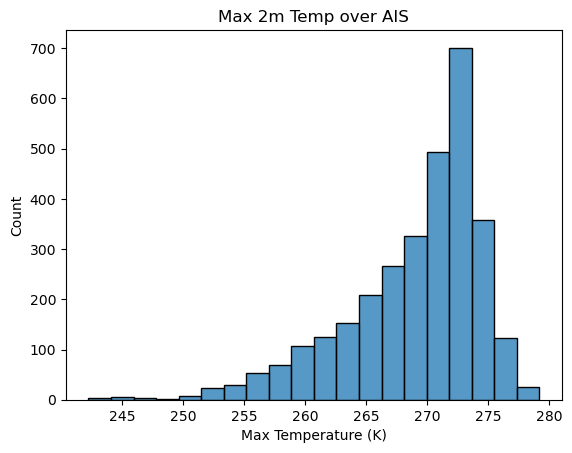

In [28]:
sns.histplot(data=catalog, x='max_T2m_ais', bins=20);
plt.title('Max 2m Temp over AIS');
plt.xlabel('Max Temperature (K)');

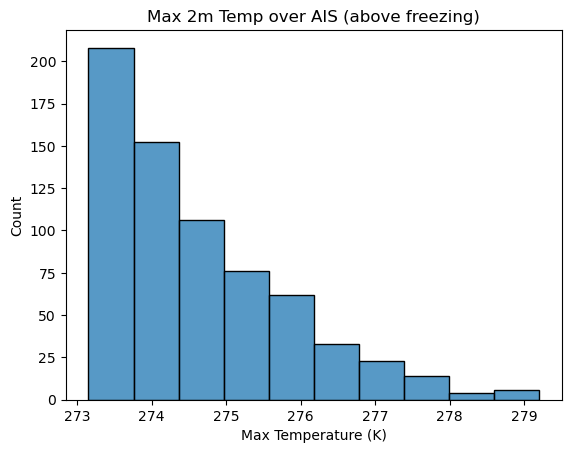

In [29]:
above_freezing = catalog.loc[catalog.max_T2m_ais >= 273.15]
sns.histplot(x=above_freezing.max_T2m_ais, bins=10);
plt.title('Max 2m Temp over AIS (above freezing)');
plt.xlabel('Max Temperature (K)');

**Fun Fact**: the storm with the highest landfalling temperature on the AIS was an AR that caused the Larsen A ice shelf collapse!

,data_array,start_date,end_date,max_IWV_ais,max_ocean_SLP_gradient,coarser_region,duration,max_south_extent,cumulative_landfalling_area,max_landfalling_v850hPa,max_vIVT_ais,max_T2M_anomaly_ais,cumulative_rainfall_ais,cumulative_snowfall_ais
AR Number,,,,,,,,,,,,,,
2905,,1995-01-24 00:00:00,1995-01-25 00:00:00,25.030884,6.684744,West,27.000000,-76.500000,118655.727534,35.177967,626.006409,9.236847,0.103773,0.519593

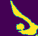

In [102]:
display_catalog(subcat.loc[[catalog.max_T2m_ais.idxmax()]])

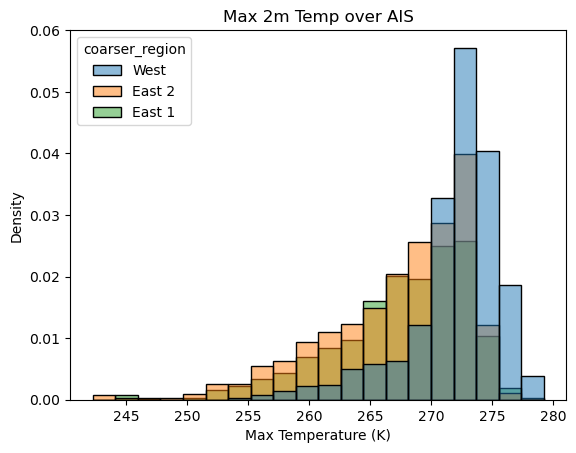

In [31]:
sns.histplot(data=catalog, x='max_T2m_ais', hue='coarser_region', bins=20, stat='density');
plt.title('Max 2m Temp over AIS');
plt.xlabel('Max Temperature (K)');

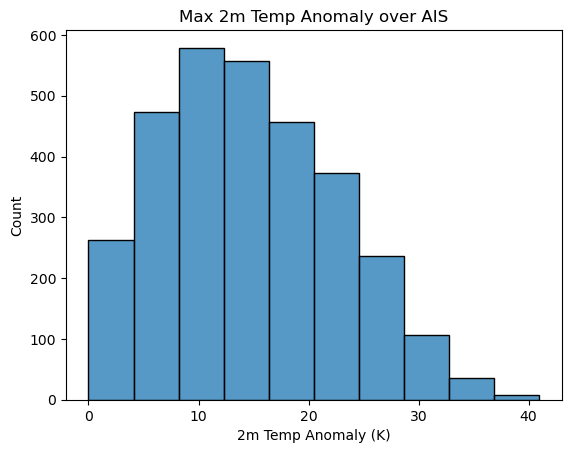

In [32]:
sns.histplot(data=subcat, x='max_T2M_anomaly_ais', bins=10);
plt.title('Max 2m Temp Anomaly over AIS');
plt.xlabel('2m Temp Anomaly (K)');

**Fun Fact**: the storm with the highest max temp anomaly over the ice sheet was the Antarctic AR!

In [105]:
display_catalog(subcat.loc[[subcat.max_T2M_anomaly_ais.idxmax()]])

,data_array,start_date,end_date,max_IWV_ais,max_ocean_SLP_gradient,coarser_region,duration,max_south_extent,cumulative_landfalling_area,max_landfalling_v850hPa,max_vIVT_ais,max_T2M_anomaly_ais,cumulative_rainfall_ais,cumulative_snowfall_ais
AR Number,,,,,,,,,,,,,,
8839,,2022-03-13 15:00:00,2022-03-18 06:00:00,23.074251,8.060711,East 2,114.000000,-85.000000,7258223.632465,32.607830,482.539856,40.972366,0.067925,7.052556


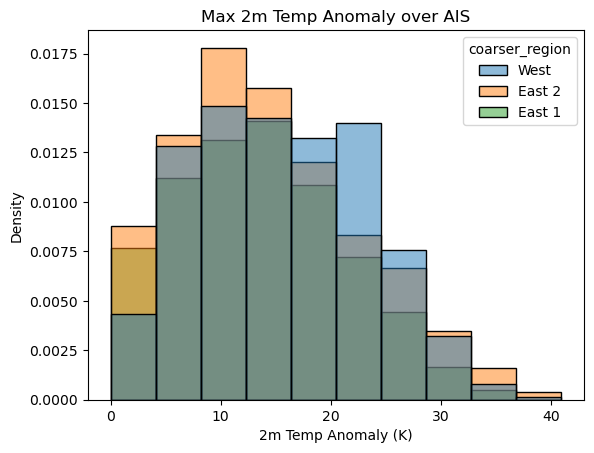

In [36]:
sns.histplot(data=subcat, x='max_T2M_anomaly_ais', hue='coarser_region', stat='density', bins=10);
plt.title('Max 2m Temp Anomaly over AIS');
plt.xlabel('2m Temp Anomaly (K)');

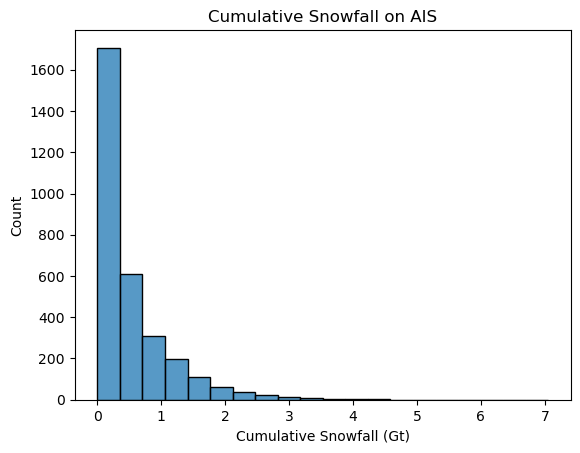

In [37]:
sns.histplot(data=subcat, x='cumulative_snowfall_ais', bins=20);
plt.title('Cumulative Snowfall on AIS');
plt.xlabel('Cumulative Snowfall (Gt)');

**Fun Fact**: the storm that dumped the most snowfall on record of any AR in the catalog was the one that caused the 2022 heat wave.

In [38]:
display_catalog(subcat.loc[[subcat.cumulative_snowfall_ais.idxmax()]])

,data_array,start_date,end_date,max_IWV_ais,max_ocean_SLP_gradient,coarser_region,duration,max_south_extent,cumulative_landfalling_area,max_landfalling_v850hPa,max_vIVT_ais,max_T2M_anomaly_ais,cumulative_rainfall_ais,cumulative_snowfall_ais
AR Number,,,,,,,,,,,,,,
8839,,2022-03-13 15:00:00,2022-03-18 06:00:00,23.074251,8.060711,East 2,114.000000,-85.000000,7258223.632465,32.607830,482.539856,40.972366,0.067925,7.052556


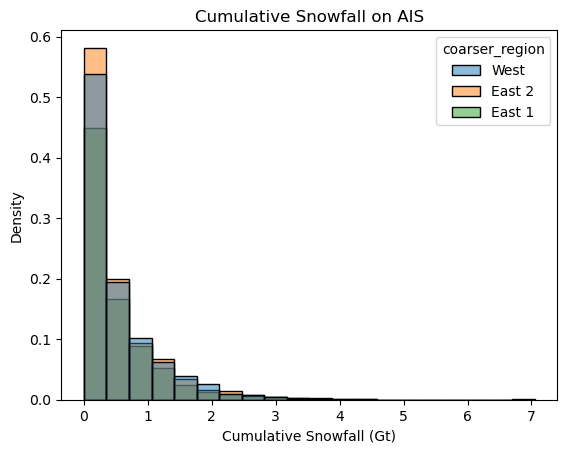

In [39]:
sns.histplot(data=subcat, x='cumulative_snowfall_ais', hue='coarser_region', bins=20, stat='density');
plt.title('Cumulative Snowfall on AIS');
plt.xlabel('Cumulative Snowfall (Gt)');

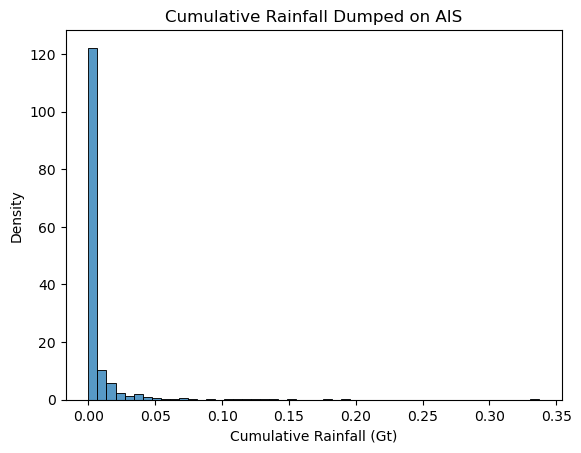

In [40]:
sns.histplot(data=subcat.loc[subcat.cumulative_rainfall_ais > 0], x='cumulative_rainfall_ais', bins=50);
plt.title('Cumulative Rainfall Dumped on AIS');
plt.xlabel('Cumulative Rainfall (Gt)');

**Fun Fact**: storm that dumped the most rain on record (almost twice the amount of rain as the next biggest storm) is an AR from February 2022, studied in Gorodestskaya et al. (2023) (*Record-high Antarctic Peninsula temperatures and surface melt in February 2022: a compound event with an intense atmospheric river*)

In [113]:
display_catalog(subcat.loc[[subcat.cumulative_rainfall_ais.idxmax()]])

,data_array,start_date,end_date,max_IWV_ais,max_ocean_SLP_gradient,coarser_region,duration,max_south_extent,cumulative_landfalling_area,max_landfalling_v850hPa,max_vIVT_ais,max_T2M_anomaly_ais,cumulative_rainfall_ais,cumulative_snowfall_ais
AR Number,,,,,,,,,,,,,,
8822,,2022-02-05 12:00:00,2022-02-09 06:00:00,27.609982,4.854247,West,93.000000,-85.000000,2759381.219366,29.558201,748.183411,20.089249,0.337306,3.272646


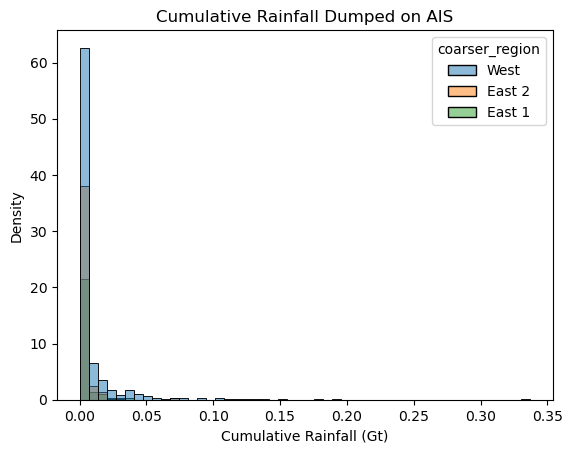

In [41]:
sns.histplot(data=subcat.loc[subcat.cumulative_rainfall_ais > 0], x='cumulative_rainfall_ais', hue='coarser_region', bins=50,  stat='density');
plt.title('Cumulative Rainfall Dumped on AIS');
plt.xlabel('Cumulative Rainfall (Gt)');

Among all ARs, every AR dumped some snow. Among those ARs, about 40% of them also dumped rain.

In [114]:
data_crosstab = pd.crosstab(subcat.cumulative_rainfall_ais > 0, 
                            subcat.cumulative_snowfall_ais > 0,  
                               margins = False, normalize='all') 
data_crosstab

cumulative_snowfall_ais,True
cumulative_rainfall_ais,
False,0.600454
True,0.399546


## Time Trend Plots

In [147]:
subsubcat.columns

Index(['start_date', 'max_IWV_ais', 'max_ocean_SLP_gradient', 'duration',
       'max_south_extent', 'cumulative_landfalling_area',
       'max_landfalling_v850hPa', 'max_vIVT_ais', 'max_T2M_anomaly_ais',
       'cumulative_rainfall_ais', 'cumulative_snowfall_ais', 'year'],
      dtype='object')

In [102]:
subsubcat = subcat.drop(columns=['data_array', 'end_date', 'coarser_region'])
subsubcat['year'] = subsubcat.start_date.dt.year
averages = subsubcat.groupby('year')[['cumulative_snowfall_ais', 'cumulative_rainfall_ais', 'max_IWV_ais', 'avg_vIVT_ais', 'max_ocean_SLP_gradient', 'max_landfalling_v850hPa', 'max_T2M_anomaly_ais', 'max_vIVT_ais', 'duration']].mean()
pct_90 = subsubcat.groupby('year')[['cumulative_snowfall_ais', 'cumulative_rainfall_ais', 'max_IWV_ais', 'avg_vIVT_ais', 'max_ocean_SLP_gradient', 'max_landfalling_v850hPa', 'max_T2M_anomaly_ais', 'max_vIVT_ais', 'duration']].quantile(q=.9)

TypeError: 'quantile' cannot be performed against 'object' dtypes!

<Axes: xlabel='year', ylabel='avg_vIVT_ais'>

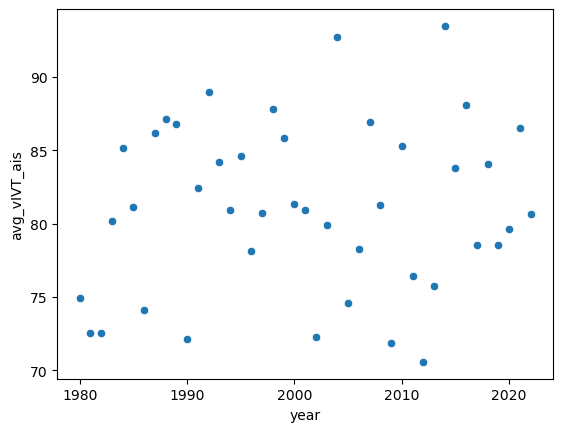

In [99]:
sns.scatterplot(data=averages, x='year', y='avg_vIVT_ais')

<Axes: xlabel='year', ylabel='max_vIVT_ais'>

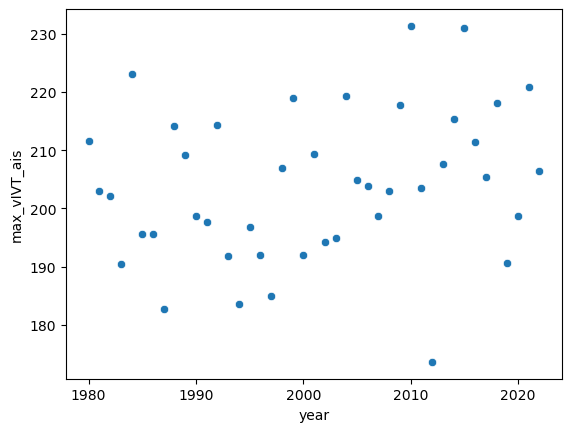

In [93]:
sns.scatterplot(data=averages, x='year', y='max_vIVT_ais')

<Axes: xlabel='year', ylabel='max_IWV_ais'>

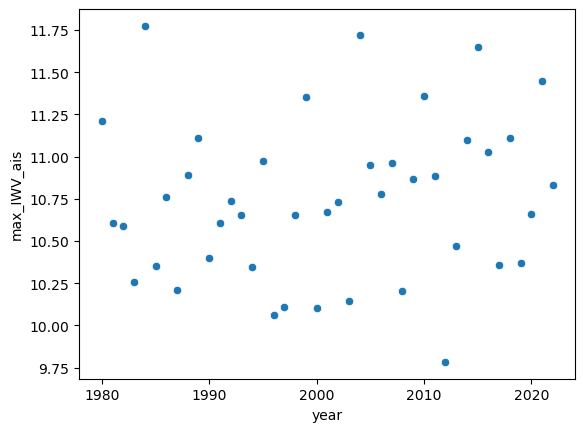

In [160]:
sns.scatterplot(data=averages, x='year', y='max_IWV_ais')

<Axes: xlabel='year', ylabel='max_ocean_SLP_gradient'>

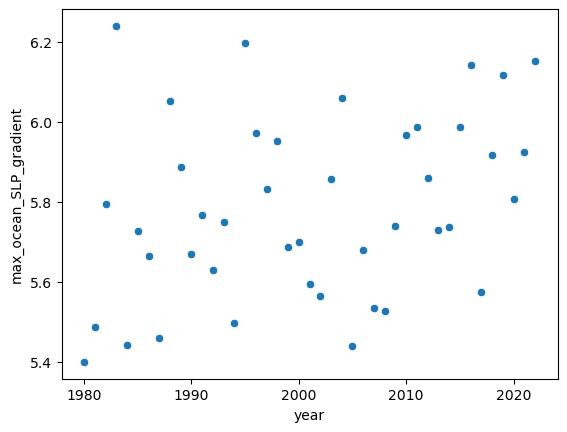

In [161]:
sns.scatterplot(data=averages, x='year', y='max_ocean_SLP_gradient')

<Axes: xlabel='year', ylabel='max_landfalling_v850hPa'>

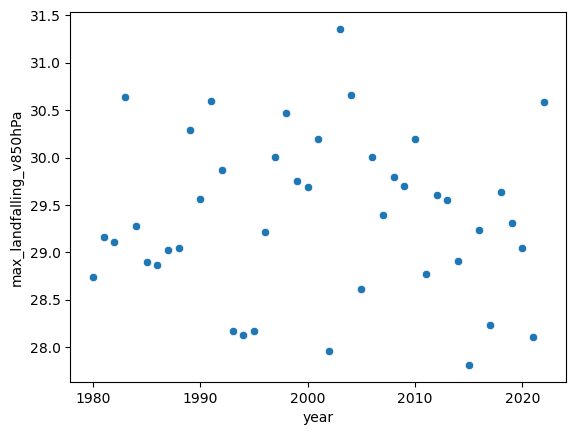

In [162]:
sns.scatterplot(data=averages, x='year', y='max_landfalling_v850hPa')

<Axes: xlabel='year', ylabel='duration'>

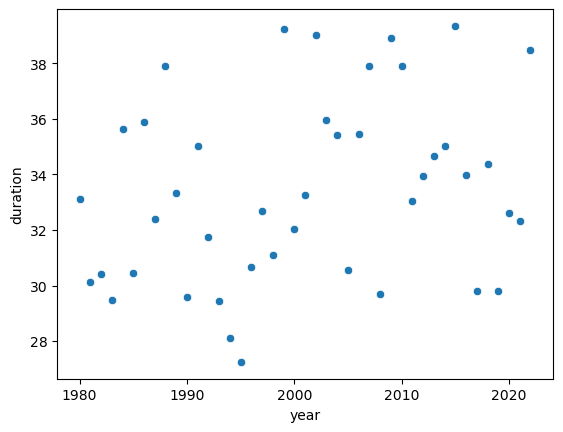

In [163]:
sns.scatterplot(data=averages, x='year', y='duration')

<Axes: xlabel='year', ylabel='max_T2M_anomaly_ais'>

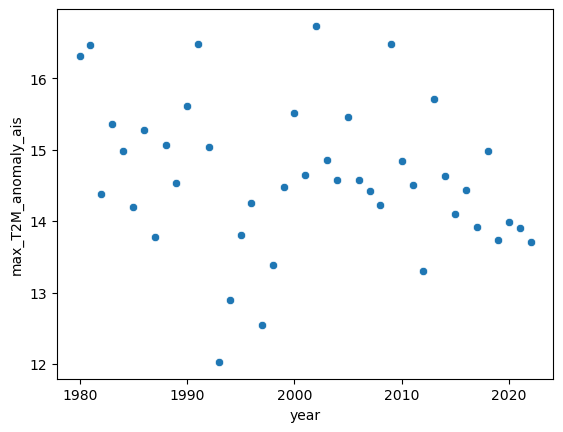

In [164]:
sns.scatterplot(data=average_snow, x='year', y='max_T2M_anomaly_ais')

<Axes: xlabel='year', ylabel='cumulative_rainfall_ais'>

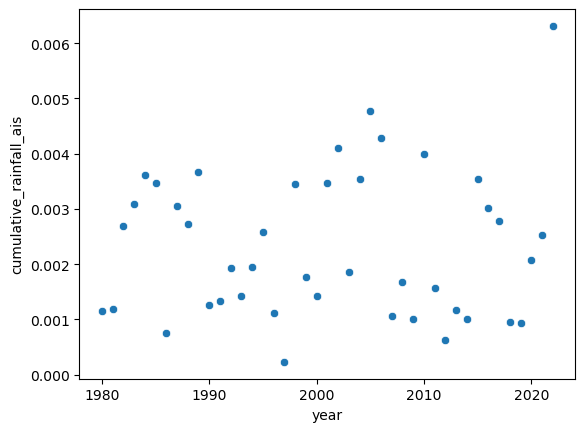

In [151]:
sns.scatterplot(data=average_snow, x='year', y='cumulative_rainfall_ais')

<Axes: xlabel='year', ylabel='cumulative_snowfall_ais'>

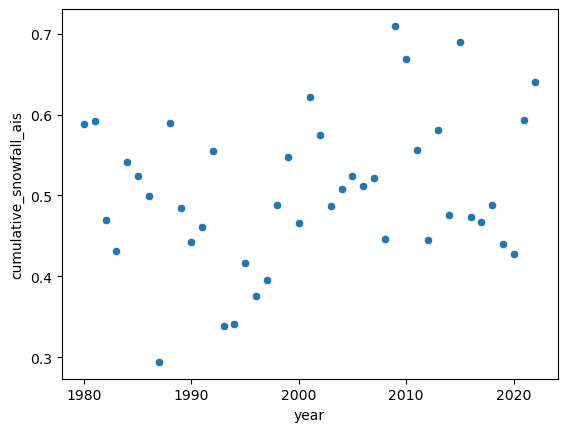

In [146]:
sns.scatterplot(data=average_snow, x='year', y='cumulative_snowfall_ais')

In [170]:
subsubcat = subcat.drop(columns=['data_array', 'end_date'])
subsubcat['year'] = subsubcat.start_date.dt.year
averages = subsubcat.groupby(['year', 'coarser_region'])[['cumulative_snowfall_ais', 'cumulative_rainfall_ais', 'max_IWV_ais', 'max_ocean_SLP_gradient', 'max_landfalling_v850hPa', 'max_T2M_anomaly_ais', 'max_vIVT_ais', 'duration']].mean()
averages = averages.reset_index()


<Axes: xlabel='year', ylabel='max_IWV_ais'>

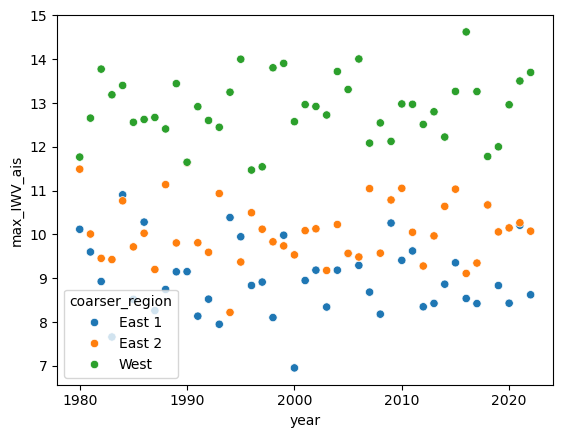

In [174]:
sns.scatterplot(data=averages, x='year', y='max_IWV_ais', hue='coarser_region')

<Axes: xlabel='year', ylabel='max_ocean_SLP_gradient'>

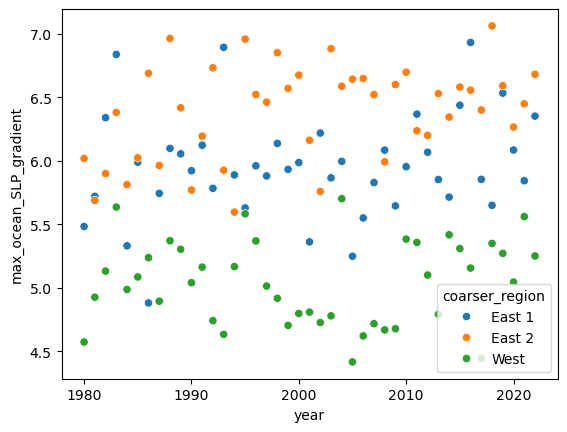

In [175]:
sns.scatterplot(data=averages, x='year', y='max_ocean_SLP_gradient', hue='coarser_region')

<Axes: xlabel='year', ylabel='max_landfalling_v850hPa'>

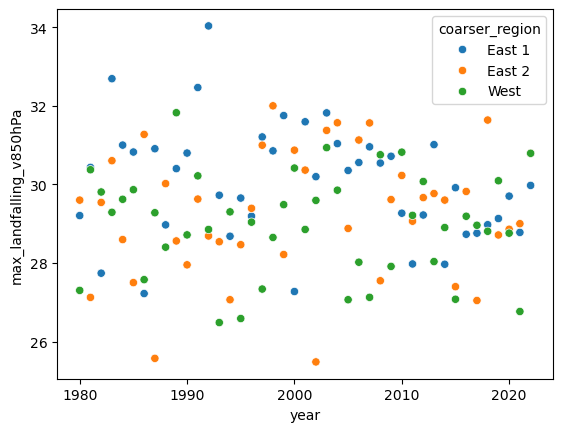

In [179]:
sns.scatterplot(data=averages, x='year', y='max_landfalling_v850hPa', hue='coarser_region')

<Axes: xlabel='year', ylabel='duration'>

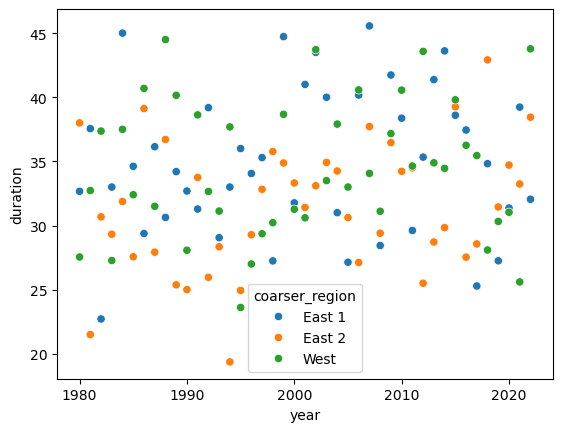

In [180]:
sns.scatterplot(data=averages, x='year', y='duration', hue='coarser_region')

<Axes: xlabel='year', ylabel='max_T2M_anomaly_ais'>

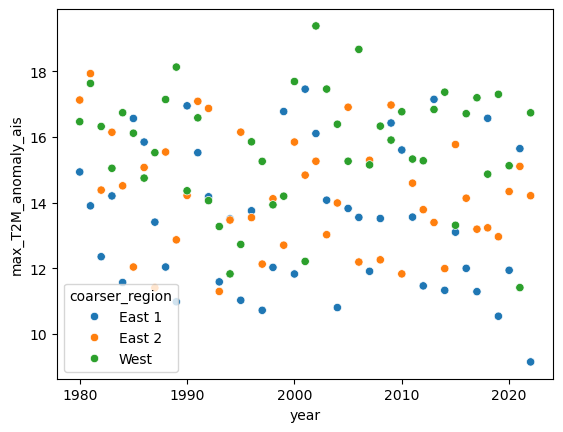

In [183]:
sns.scatterplot(data=averages, x='year', y='max_T2M_anomaly_ais', hue='coarser_region')

<Axes: xlabel='year', ylabel='cumulative_rainfall_ais'>

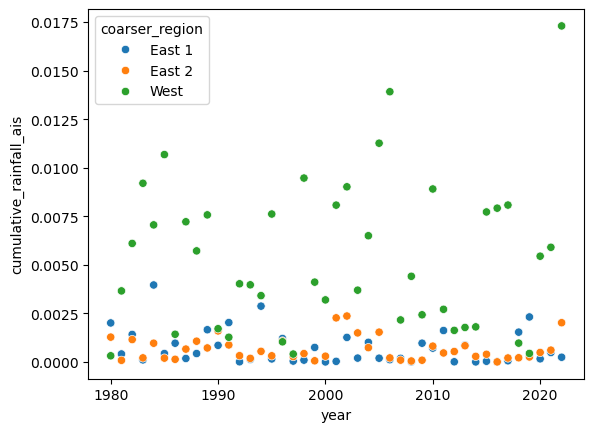

In [184]:
sns.scatterplot(data=averages, x='year', y='cumulative_rainfall_ais', hue='coarser_region')

<Axes: xlabel='year', ylabel='cumulative_snowfall_ais'>

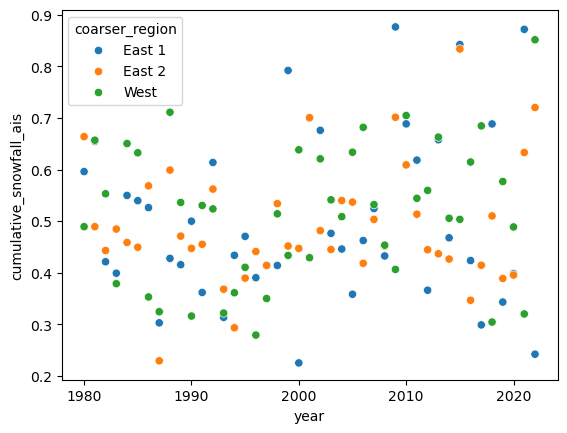

In [185]:
sns.scatterplot(data=averages, x='year', y='cumulative_snowfall_ais', hue='coarser_region')

## Multi-variable Plots

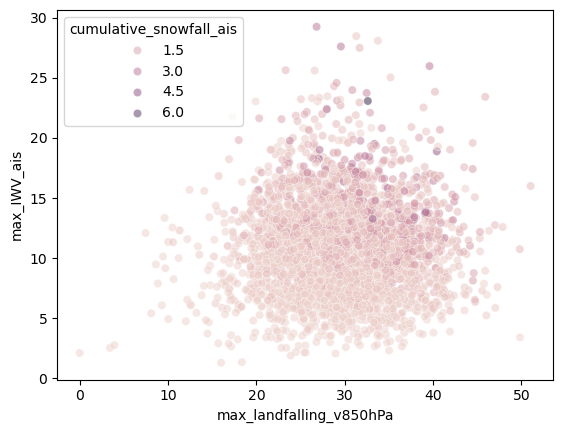

In [12]:
sns.scatterplot(data=subcat, x='max_landfalling_v850hPa', y='max_IWV_ais', hue='cumulative_snowfall_ais', alpha=0.5);

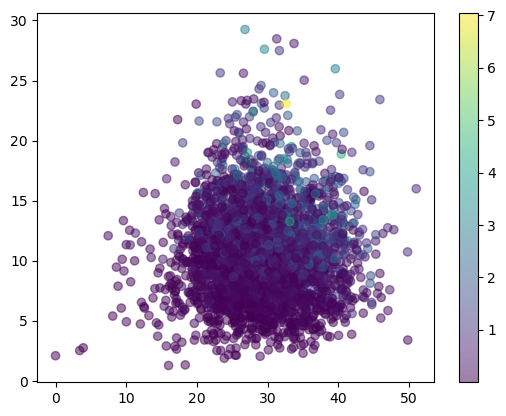

In [17]:
plt.scatter(x=subcat['max_landfalling_v850hPa'], y=subcat['max_IWV_ais'], c=subcat['cumulative_snowfall_ais'], alpha=0.5)
plt.colorbar()

In [90]:
from matplotlib import colormaps as cm

max_snow = subcat['cumulative_snowfall_ais'].max()
min_snow = subcat['cumulative_snowfall_ais'].min()

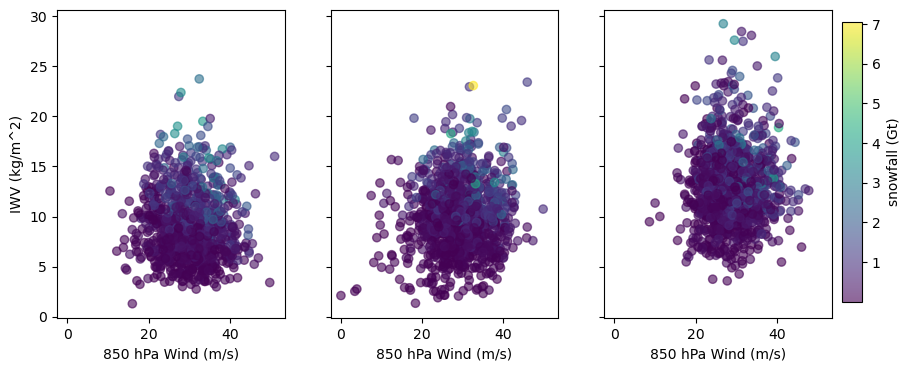

In [91]:
fig, axs = plt.subplots(nrows=1, ncols=3, sharey=True, sharex=True)
region_cat = subcat[subcat.coarser_region == 'East 1']
axs[0].scatter(x=region_cat['max_landfalling_v850hPa'], y=region_cat['max_IWV_ais'], c=region_cat['cumulative_snowfall_ais'], alpha=0.6, vmin=min_snow, vmax=max_snow, cmap=cm['viridis'])
axs[0].set_ylabel('IWV (kg/m^2)')
axs[0].set_xlabel('850 hPa Wind (m/s)')
region_cat = subcat[subcat.coarser_region == 'East 2']
axs[1].scatter(x=region_cat['max_landfalling_v850hPa'], y=region_cat['max_IWV_ais'], c=region_cat['cumulative_snowfall_ais'], alpha=0.6, vmin=min_snow, vmax=max_snow, cmap=cm['viridis'])
axs[1].set_xlabel('850 hPa Wind (m/s)')
region_cat = subcat[subcat.coarser_region == 'West']
im = axs[2].scatter(x=region_cat['max_landfalling_v850hPa'], y=region_cat['max_IWV_ais'], c=region_cat['cumulative_snowfall_ais'], alpha=0.6, vmin=min_snow, vmax=max_snow, cmap=cm['viridis'])
axs[2].set_xlabel('850 hPa Wind (m/s)')
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
fig.colorbar(im, cbar_ax, label = 'snowfall (Gt)')
fig.set_size_inches(10, 4);

In [88]:
above_median = subcat.loc[subcat['cumulative_snowfall_ais'] > subcat['cumulative_snowfall_ais'].quantile(0.75)]
max_snow = above_median['cumulative_snowfall_ais'].max()
min_snow = above_median['cumulative_snowfall_ais'].min()

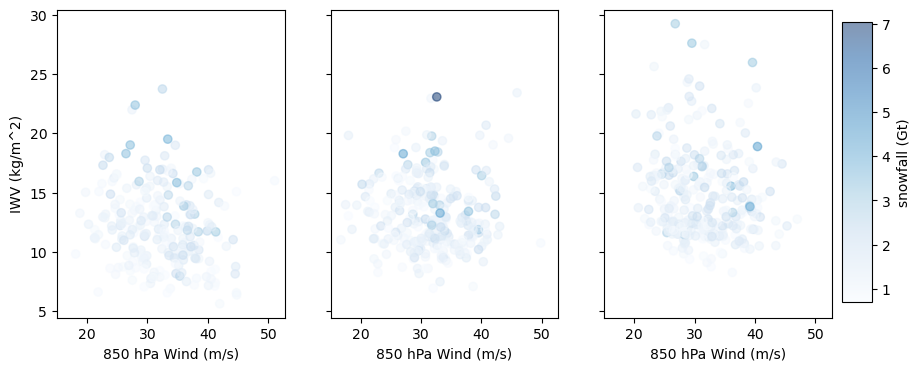

In [89]:
fig, axs = plt.subplots(nrows=1, ncols=3, sharey=True, sharex=True)
region_cat = above_median[above_median.coarser_region == 'East 1']
axs[0].scatter(x=region_cat['max_landfalling_v850hPa'], y=region_cat['max_IWV_ais'], c=region_cat['cumulative_snowfall_ais'], alpha=0.5, vmin=min_snow, vmax=max_snow, cmap=cm['Blues'])
axs[0].set_ylabel('IWV (kg/m^2)')
axs[0].set_xlabel('850 hPa Wind (m/s)')
region_cat = above_median[above_median.coarser_region == 'East 2']
axs[1].scatter(x=region_cat['max_landfalling_v850hPa'], y=region_cat['max_IWV_ais'], c=region_cat['cumulative_snowfall_ais'], alpha=0.5, vmin=min_snow, vmax=max_snow, cmap=cm['Blues'])
axs[1].set_xlabel('850 hPa Wind (m/s)')
region_cat = above_median[above_median.coarser_region == 'West']
im = axs[2].scatter(x=region_cat['max_landfalling_v850hPa'], y=region_cat['max_IWV_ais'], c=region_cat['cumulative_snowfall_ais'], alpha=0.5, vmin=min_snow, vmax=max_snow, cmap=cm['Blues'])
axs[2].set_xlabel('850 hPa Wind (m/s)')
cbar_ax = fig.add_axes([0.91, 0.15, 0.03, 0.7])
fig.colorbar(im, cbar_ax, label = 'snowfall (Gt)')
fig.set_size_inches(10, 4);

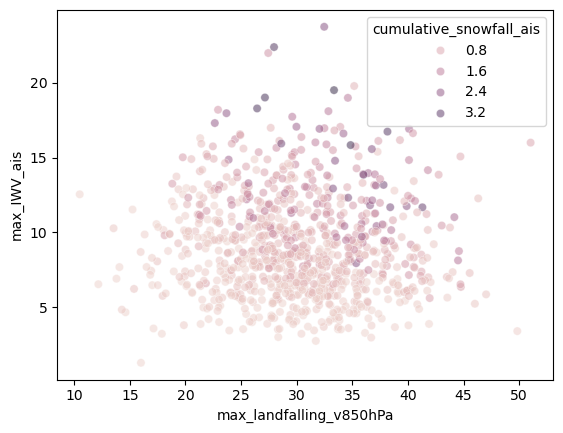

In [192]:
sns.scatterplot(data=subcat[subcat.coarser_region == 'East 1'], x='max_landfalling_v850hPa', y='max_IWV_ais', hue='cumulative_snowfall_ais', alpha=0.5);

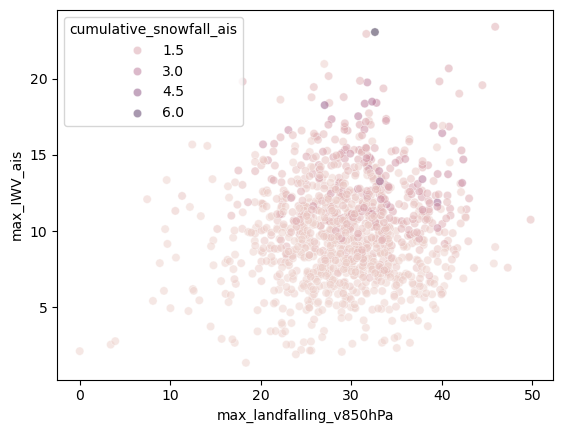

In [193]:
sns.scatterplot(data=subcat[subcat.coarser_region == 'East 2'], x='max_landfalling_v850hPa', y='max_IWV_ais', hue='cumulative_snowfall_ais', alpha=0.5);

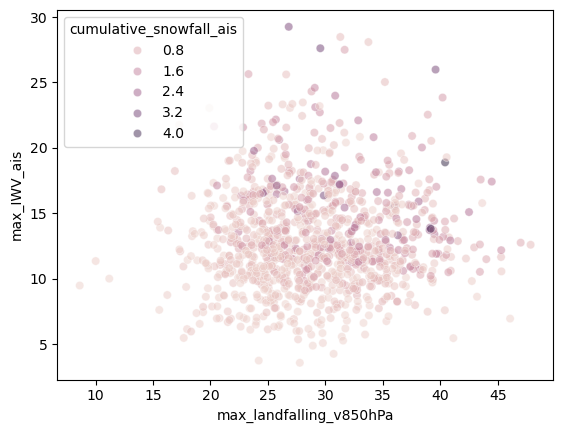

In [194]:
sns.scatterplot(data=subcat[subcat.coarser_region == 'West'], x='max_landfalling_v850hPa', y='max_IWV_ais', hue='cumulative_snowfall_ais', alpha=0.5);

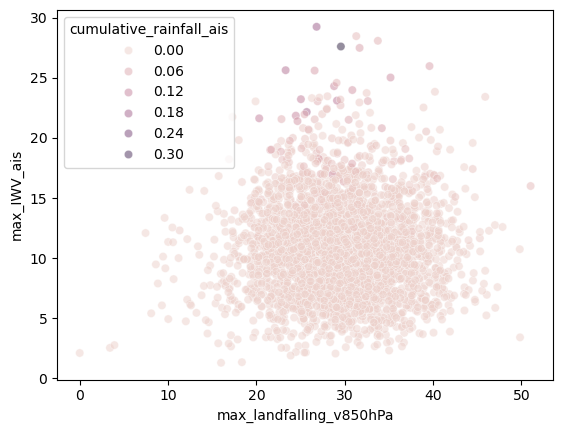

In [195]:
sns.scatterplot(data=subcat, x='max_landfalling_v850hPa', y='max_IWV_ais', hue='cumulative_rainfall_ais', alpha=0.5);

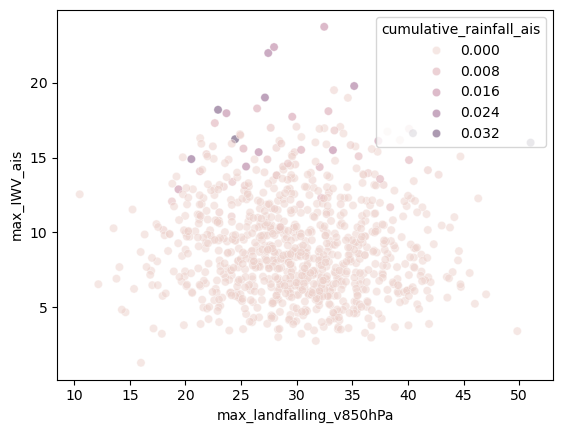

In [196]:
sns.scatterplot(data=subcat[subcat.coarser_region == 'East 1'], x='max_landfalling_v850hPa', y='max_IWV_ais', hue='cumulative_rainfall_ais', alpha=0.5);

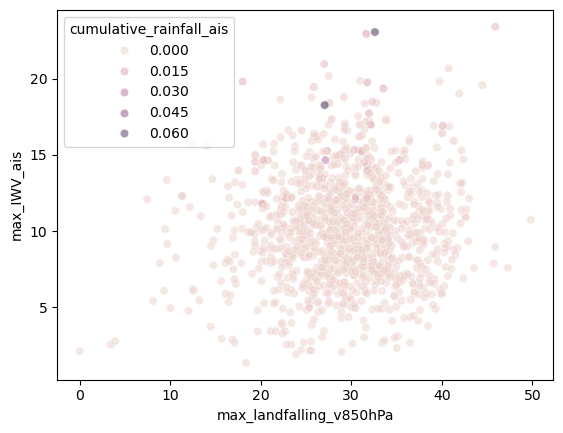

In [197]:
sns.scatterplot(data=subcat[subcat.coarser_region == 'East 2'], x='max_landfalling_v850hPa', y='max_IWV_ais', hue='cumulative_rainfall_ais', alpha=0.5);

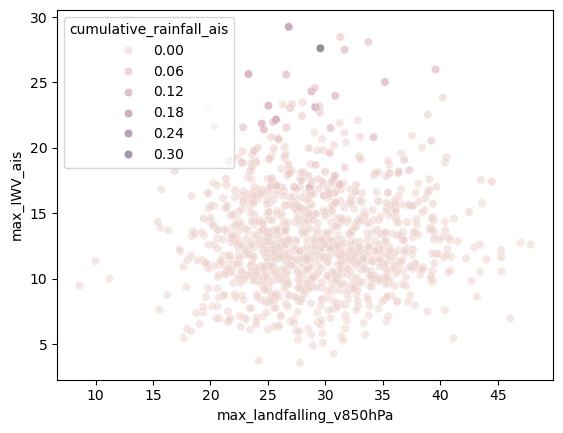

In [198]:
sns.scatterplot(data=subcat[subcat.coarser_region == 'West'], x='max_landfalling_v850hPa', y='max_IWV_ais', hue='cumulative_rainfall_ais', alpha=0.5);

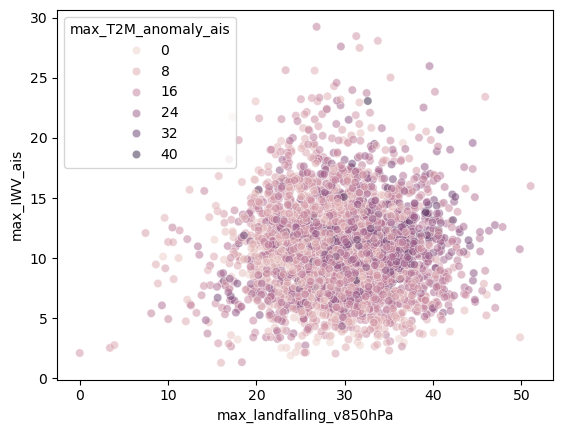

In [199]:
sns.scatterplot(data=subcat, x='max_landfalling_v850hPa', y='max_IWV_ais', hue='max_T2M_anomaly_ais', alpha=0.5);

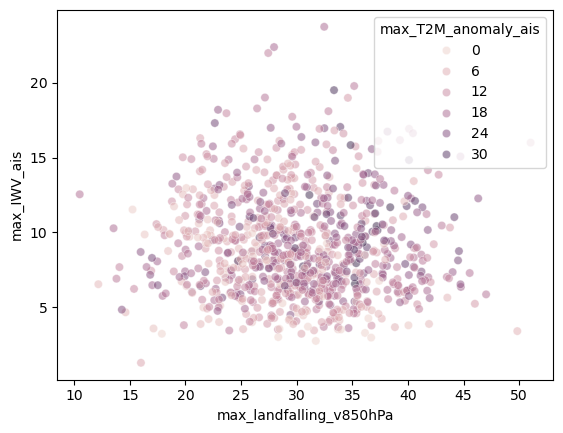

In [200]:
sns.scatterplot(data=subcat[subcat.coarser_region == 'East 1'], x='max_landfalling_v850hPa', y='max_IWV_ais', hue='max_T2M_anomaly_ais', alpha=0.5);

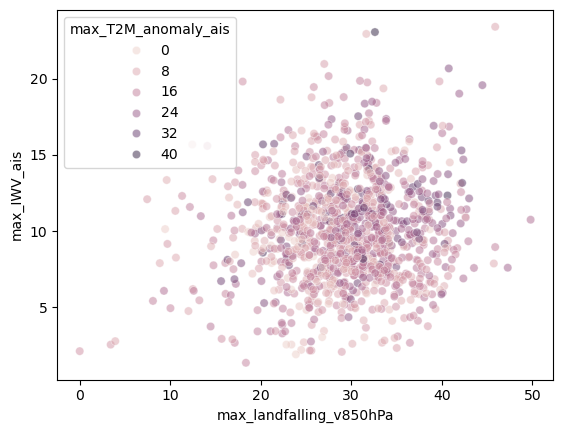

In [201]:
sns.scatterplot(data=subcat[subcat.coarser_region == 'East 2'], x='max_landfalling_v850hPa', y='max_IWV_ais', hue='max_T2M_anomaly_ais', alpha=0.5);

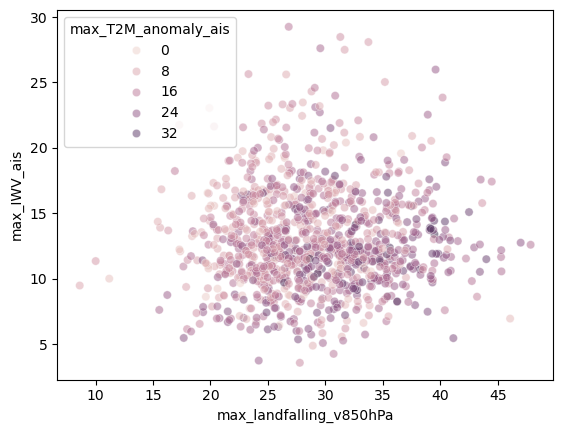

In [202]:
sns.scatterplot(data=subcat[subcat.coarser_region == 'West'], x='max_landfalling_v850hPa', y='max_IWV_ais', hue='max_T2M_anomaly_ais', alpha=0.5);

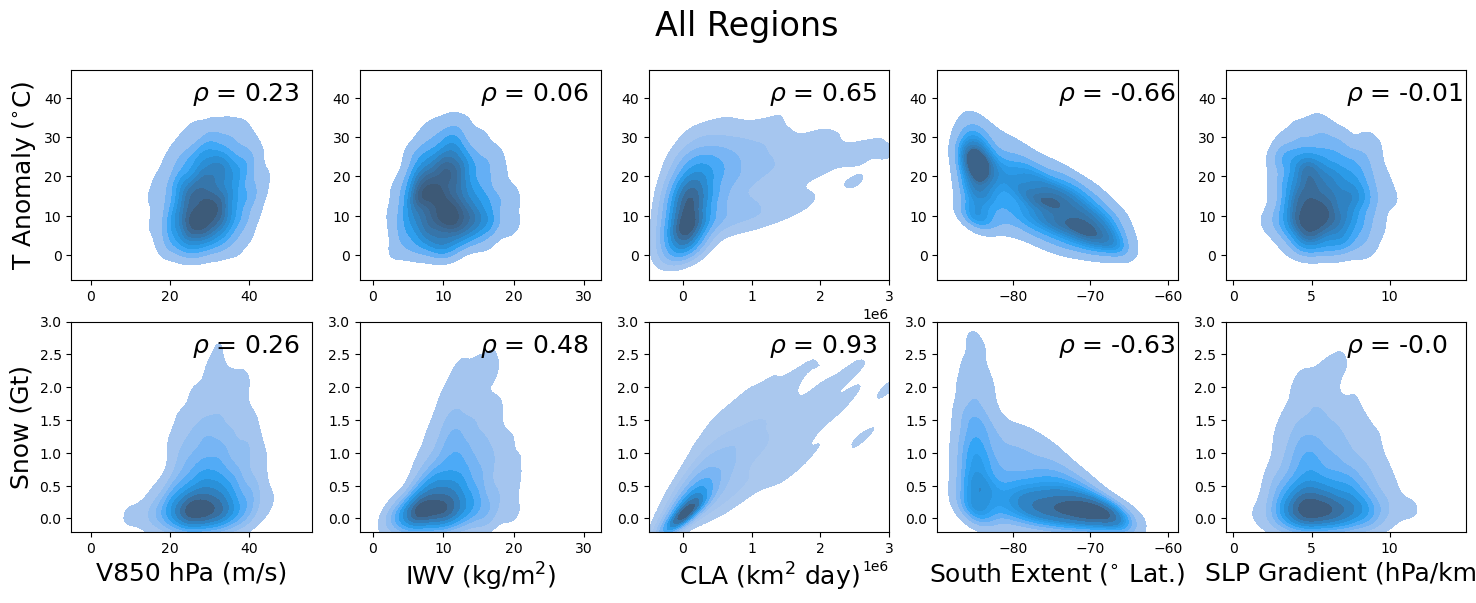

In [206]:
from scipy.stats import pearsonr
from scipy.stats import spearmanr

fig, axs = plt.subplots(nrows=2, ncols=5)
fig.set_size_inches(18, 6)
fig.suptitle('All Regions', fontsize=24)

catalog =subcat

impact1 = "max_T2M_anomaly_ais"
impact2 = "cumulative_snowfall_ais"

#fig.suptitle('Pairwise Relationships between Impacts and Covariates', fontsize=22)

corr = round(spearmanr(catalog.max_landfalling_v850hPa, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_landfalling_v850hPa", y=impact1, fill=True, ax=axs[0,0])
axs[0,0].set_xlabel('')
axs[0,0].set_ylabel('T Anomaly ($^{\\circ}$C)', fontsize=18)
axs[0,0].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_IWV_ais, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_IWV_ais", y=impact1, fill=True, ax=axs[0,1])
axs[0,1].set_xlabel('')
axs[0,1].set_ylabel('')
axs[0,1].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.cumulative_landfalling_area, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="cumulative_landfalling_area", y=impact1, fill=True, ax=axs[0,2])
axs[0,2].set_xlabel('')
axs[0,2].set_ylabel('')
axs[0,2].set_xlim(-0.5*(10**6), 3*(10**6))
axs[0,2].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_south_extent, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_south_extent", y=impact1, fill=True, ax=axs[0,3])
axs[0,3].set_xlabel('')
axs[0,3].set_ylabel('')
#axs[3].set_xlim(, 4*(10**6))
axs[0,3].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_ocean_SLP_gradient, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_ocean_SLP_gradient", y=impact1, fill=True, ax=axs[0,4])
axs[0,4].set_xlabel('')
axs[0,4].set_ylabel('')
#axs[3].set_xlim(, 4*(10**6))
axs[0,4].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_landfalling_v850hPa, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_landfalling_v850hPa", y=impact2, fill=True, ax=axs[1,0])
axs[1,0].set_xlabel('V850 hPa (m/s)', fontsize=18)
axs[1,0].set_ylabel('Snow (Gt)', fontsize=18)
axs[1,0].set_ylim(-0.2, 3)
axs[1,0].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_IWV_ais, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_IWV_ais", y=impact2, fill=True, ax=axs[1,1])
axs[1,1].set_xlabel('IWV (kg/m$^{2}$)', fontsize=18)
axs[1,1].set_ylabel('')
axs[1,1].set_ylim(-0.2, 3)
axs[1,1].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.cumulative_landfalling_area, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="cumulative_landfalling_area", y=impact2, fill=True, ax=axs[1,2])
axs[1,2].set_xlabel('CLA (km$^{2} $ day)', fontsize=18)
axs[1,2].set_xlim(-0.5*(10**6), 3*(10**6))
axs[1,2].set_ylabel('')
axs[1,2].set_ylim(-0.2, 3)
axs[1,2].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_south_extent, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_south_extent", y=impact2, fill=True, ax=axs[1,3])
axs[1,3].set_xlabel('South Extent ($^{\\circ}$ Lat.)', fontsize=18)
axs[1,3].set_ylabel('')
axs[1,3].set_ylim(-0.2, 3)
axs[1,3].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_ocean_SLP_gradient, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_ocean_SLP_gradient", y=impact2, fill=True, ax=axs[1,4])
axs[1,4].set_xlabel('SLP Gradient (hPa/km)', fontsize=18)
axs[1,4].set_ylabel('')
axs[1,4].set_ylim(-0.2, 3)
axs[1,4].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

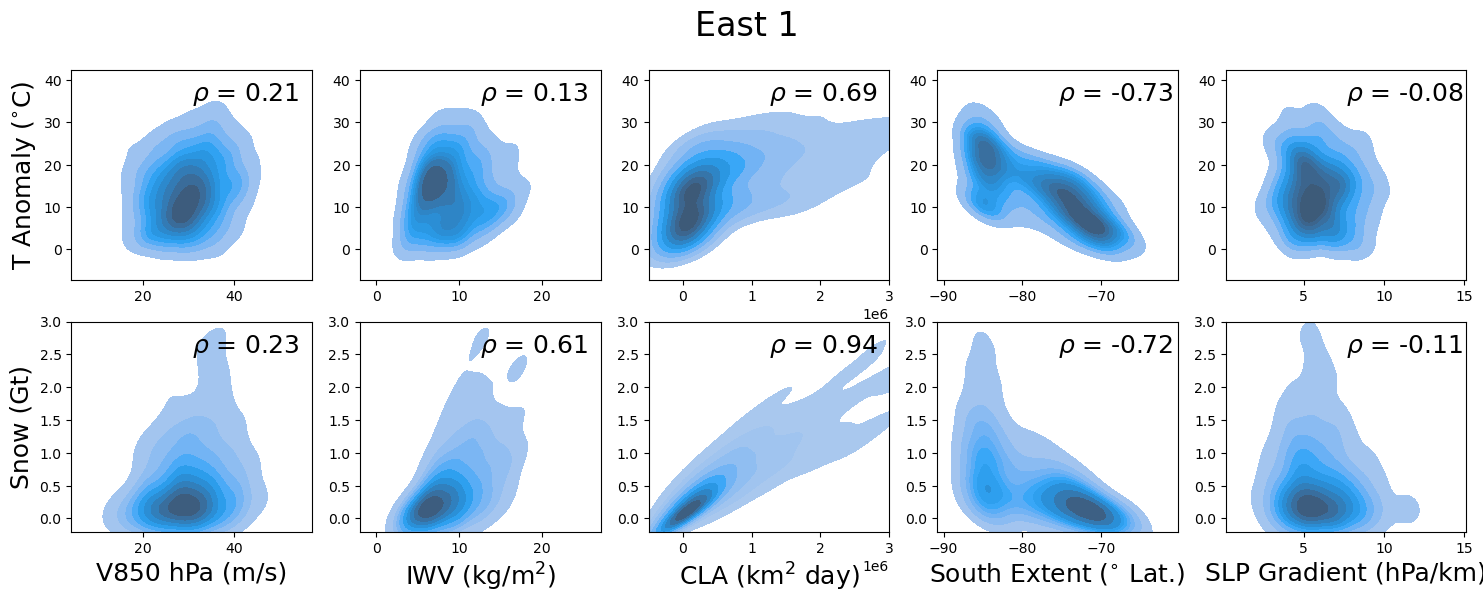

In [207]:
from scipy.stats import pearsonr
from scipy.stats import spearmanr

fig, axs = plt.subplots(nrows=2, ncols=5)
fig.set_size_inches(18, 6)
fig.suptitle('East 1', fontsize=24)

catalog = subcat[subcat.coarser_region == 'East 1']

impact1 = "max_T2M_anomaly_ais"
impact2 = "cumulative_snowfall_ais"

#fig.suptitle('Pairwise Relationships between Impacts and Covariates', fontsize=22)

corr = round(spearmanr(catalog.max_landfalling_v850hPa, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_landfalling_v850hPa", y=impact1, fill=True, ax=axs[0,0])
axs[0,0].set_xlabel('')
axs[0,0].set_ylabel('T Anomaly ($^{\\circ}$C)', fontsize=18)
axs[0,0].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_IWV_ais, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_IWV_ais", y=impact1, fill=True, ax=axs[0,1])
axs[0,1].set_xlabel('')
axs[0,1].set_ylabel('')
axs[0,1].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.cumulative_landfalling_area, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="cumulative_landfalling_area", y=impact1, fill=True, ax=axs[0,2])
axs[0,2].set_xlabel('')
axs[0,2].set_ylabel('')
axs[0,2].set_xlim(-0.5*(10**6), 3*(10**6))
axs[0,2].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_south_extent, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_south_extent", y=impact1, fill=True, ax=axs[0,3])
axs[0,3].set_xlabel('')
axs[0,3].set_ylabel('')
#axs[3].set_xlim(, 4*(10**6))
axs[0,3].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_ocean_SLP_gradient, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_ocean_SLP_gradient", y=impact1, fill=True, ax=axs[0,4])
axs[0,4].set_xlabel('')
axs[0,4].set_ylabel('')
#axs[3].set_xlim(, 4*(10**6))
axs[0,4].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_landfalling_v850hPa, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_landfalling_v850hPa", y=impact2, fill=True, ax=axs[1,0])
axs[1,0].set_xlabel('V850 hPa (m/s)', fontsize=18)
axs[1,0].set_ylabel('Snow (Gt)', fontsize=18)
axs[1,0].set_ylim(-0.2, 3)
axs[1,0].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_IWV_ais, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_IWV_ais", y=impact2, fill=True, ax=axs[1,1])
axs[1,1].set_xlabel('IWV (kg/m$^{2}$)', fontsize=18)
axs[1,1].set_ylabel('')
axs[1,1].set_ylim(-0.2, 3)
axs[1,1].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.cumulative_landfalling_area, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="cumulative_landfalling_area", y=impact2, fill=True, ax=axs[1,2])
axs[1,2].set_xlabel('CLA (km$^{2} $ day)', fontsize=18)
axs[1,2].set_xlim(-0.5*(10**6), 3*(10**6))
axs[1,2].set_ylabel('')
axs[1,2].set_ylim(-0.2, 3)
axs[1,2].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_south_extent, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_south_extent", y=impact2, fill=True, ax=axs[1,3])
axs[1,3].set_xlabel('South Extent ($^{\\circ}$ Lat.)', fontsize=18)
axs[1,3].set_ylabel('')
axs[1,3].set_ylim(-0.2, 3)
axs[1,3].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_ocean_SLP_gradient, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_ocean_SLP_gradient", y=impact2, fill=True, ax=axs[1,4])
axs[1,4].set_xlabel('SLP Gradient (hPa/km)', fontsize=18)
axs[1,4].set_ylabel('')
axs[1,4].set_ylim(-0.2, 3)
axs[1,4].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

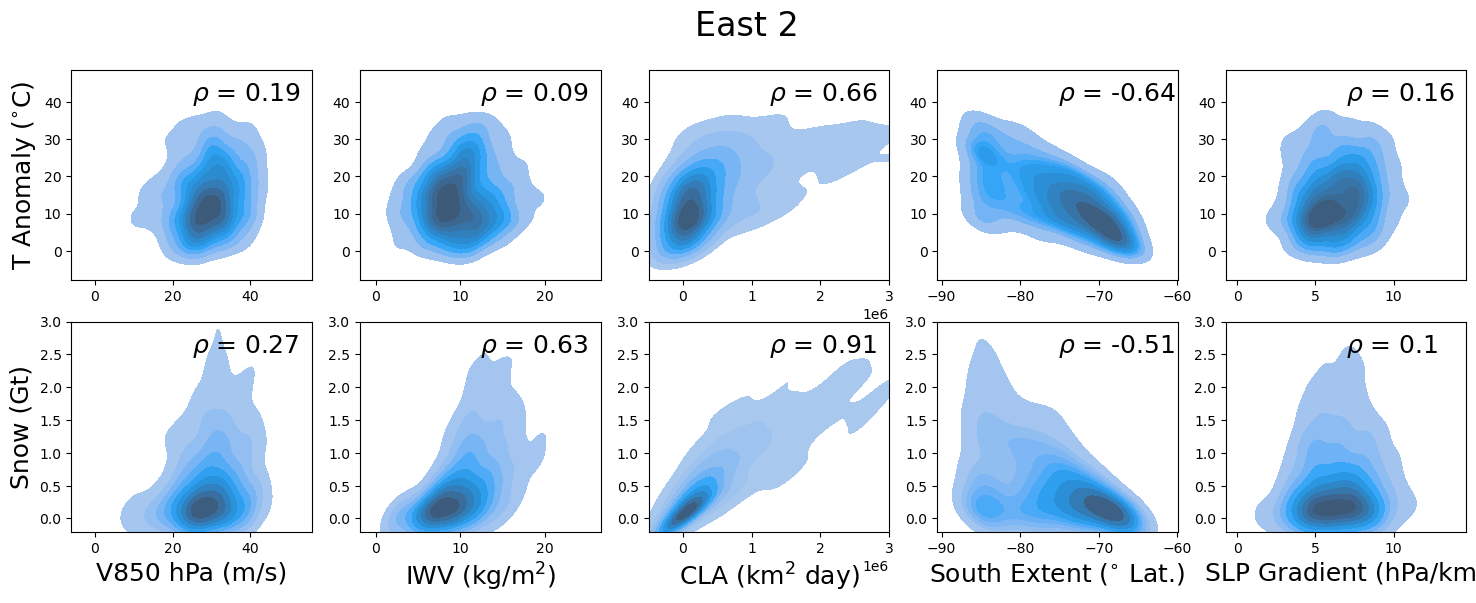

In [208]:
from scipy.stats import pearsonr
from scipy.stats import spearmanr

fig, axs = plt.subplots(nrows=2, ncols=5)
fig.set_size_inches(18, 6)
fig.suptitle('East 2', fontsize=24)

catalog = subcat[subcat.coarser_region == 'East 2']

impact1 = "max_T2M_anomaly_ais"
impact2 = "cumulative_snowfall_ais"

#fig.suptitle('Pairwise Relationships between Impacts and Covariates', fontsize=22)

corr = round(spearmanr(catalog.max_landfalling_v850hPa, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_landfalling_v850hPa", y=impact1, fill=True, ax=axs[0,0])
axs[0,0].set_xlabel('')
axs[0,0].set_ylabel('T Anomaly ($^{\\circ}$C)', fontsize=18)
axs[0,0].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_IWV_ais, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_IWV_ais", y=impact1, fill=True, ax=axs[0,1])
axs[0,1].set_xlabel('')
axs[0,1].set_ylabel('')
axs[0,1].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.cumulative_landfalling_area, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="cumulative_landfalling_area", y=impact1, fill=True, ax=axs[0,2])
axs[0,2].set_xlabel('')
axs[0,2].set_ylabel('')
axs[0,2].set_xlim(-0.5*(10**6), 3*(10**6))
axs[0,2].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_south_extent, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_south_extent", y=impact1, fill=True, ax=axs[0,3])
axs[0,3].set_xlabel('')
axs[0,3].set_ylabel('')
#axs[3].set_xlim(, 4*(10**6))
axs[0,3].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_ocean_SLP_gradient, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_ocean_SLP_gradient", y=impact1, fill=True, ax=axs[0,4])
axs[0,4].set_xlabel('')
axs[0,4].set_ylabel('')
#axs[3].set_xlim(, 4*(10**6))
axs[0,4].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_landfalling_v850hPa, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_landfalling_v850hPa", y=impact2, fill=True, ax=axs[1,0])
axs[1,0].set_xlabel('V850 hPa (m/s)', fontsize=18)
axs[1,0].set_ylabel('Snow (Gt)', fontsize=18)
axs[1,0].set_ylim(-0.2, 3)
axs[1,0].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_IWV_ais, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_IWV_ais", y=impact2, fill=True, ax=axs[1,1])
axs[1,1].set_xlabel('IWV (kg/m$^{2}$)', fontsize=18)
axs[1,1].set_ylabel('')
axs[1,1].set_ylim(-0.2, 3)
axs[1,1].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.cumulative_landfalling_area, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="cumulative_landfalling_area", y=impact2, fill=True, ax=axs[1,2])
axs[1,2].set_xlabel('CLA (km$^{2} $ day)', fontsize=18)
axs[1,2].set_xlim(-0.5*(10**6), 3*(10**6))
axs[1,2].set_ylabel('')
axs[1,2].set_ylim(-0.2, 3)
axs[1,2].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_south_extent, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_south_extent", y=impact2, fill=True, ax=axs[1,3])
axs[1,3].set_xlabel('South Extent ($^{\\circ}$ Lat.)', fontsize=18)
axs[1,3].set_ylabel('')
axs[1,3].set_ylim(-0.2, 3)
axs[1,3].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_ocean_SLP_gradient, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_ocean_SLP_gradient", y=impact2, fill=True, ax=axs[1,4])
axs[1,4].set_xlabel('SLP Gradient (hPa/km)', fontsize=18)
axs[1,4].set_ylabel('')
axs[1,4].set_ylim(-0.2, 3)
axs[1,4].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

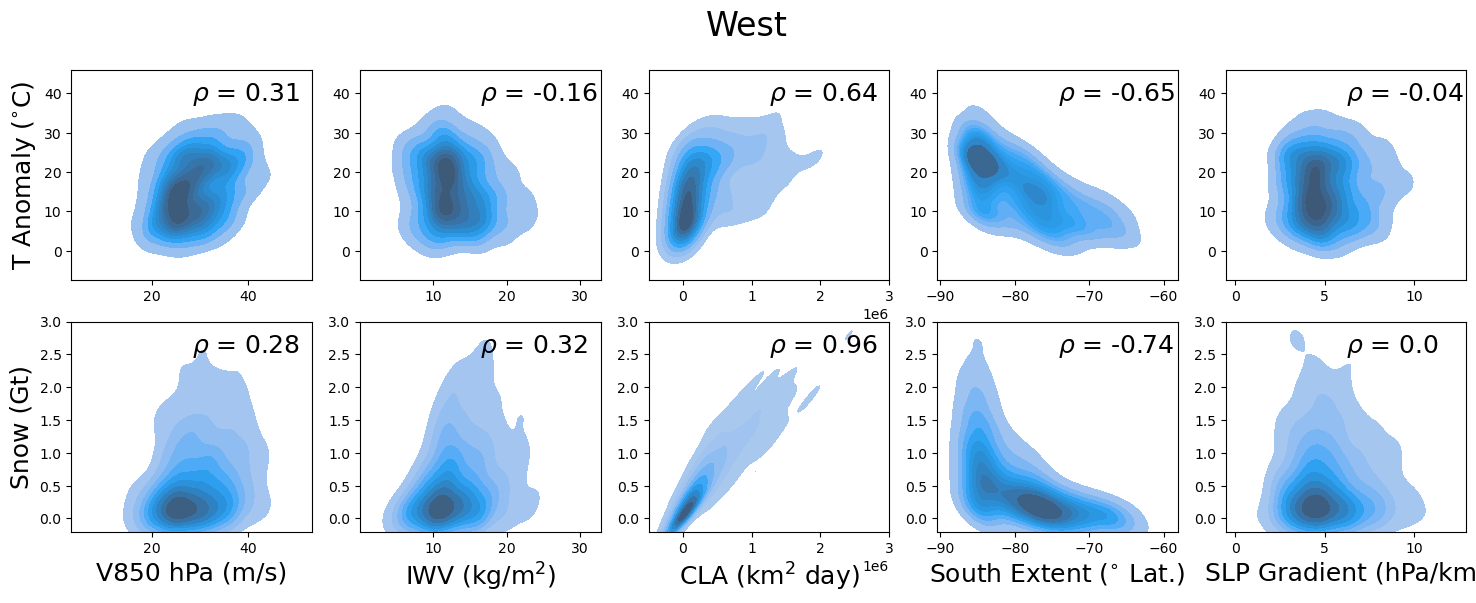

In [209]:
from scipy.stats import pearsonr
from scipy.stats import spearmanr

fig, axs = plt.subplots(nrows=2, ncols=5)
fig.set_size_inches(18, 6)
fig.suptitle('West', fontsize=24)

catalog = subcat[subcat.coarser_region == 'West']

impact1 = "max_T2M_anomaly_ais"
impact2 = "cumulative_snowfall_ais"

#fig.suptitle('Pairwise Relationships between Impacts and Covariates', fontsize=22)

corr = round(spearmanr(catalog.max_landfalling_v850hPa, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_landfalling_v850hPa", y=impact1, fill=True, ax=axs[0,0])
axs[0,0].set_xlabel('')
axs[0,0].set_ylabel('T Anomaly ($^{\\circ}$C)', fontsize=18)
axs[0,0].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_IWV_ais, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_IWV_ais", y=impact1, fill=True, ax=axs[0,1])
axs[0,1].set_xlabel('')
axs[0,1].set_ylabel('')
axs[0,1].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.cumulative_landfalling_area, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="cumulative_landfalling_area", y=impact1, fill=True, ax=axs[0,2])
axs[0,2].set_xlabel('')
axs[0,2].set_ylabel('')
axs[0,2].set_xlim(-0.5*(10**6), 3*(10**6))
axs[0,2].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_south_extent, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_south_extent", y=impact1, fill=True, ax=axs[0,3])
axs[0,3].set_xlabel('')
axs[0,3].set_ylabel('')
#axs[3].set_xlim(, 4*(10**6))
axs[0,3].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_ocean_SLP_gradient, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_ocean_SLP_gradient", y=impact1, fill=True, ax=axs[0,4])
axs[0,4].set_xlabel('')
axs[0,4].set_ylabel('')
#axs[3].set_xlim(, 4*(10**6))
axs[0,4].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_landfalling_v850hPa, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_landfalling_v850hPa", y=impact2, fill=True, ax=axs[1,0])
axs[1,0].set_xlabel('V850 hPa (m/s)', fontsize=18)
axs[1,0].set_ylabel('Snow (Gt)', fontsize=18)
axs[1,0].set_ylim(-0.2, 3)
axs[1,0].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_IWV_ais, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_IWV_ais", y=impact2, fill=True, ax=axs[1,1])
axs[1,1].set_xlabel('IWV (kg/m$^{2}$)', fontsize=18)
axs[1,1].set_ylabel('')
axs[1,1].set_ylim(-0.2, 3)
axs[1,1].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.cumulative_landfalling_area, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="cumulative_landfalling_area", y=impact2, fill=True, ax=axs[1,2])
axs[1,2].set_xlabel('CLA (km$^{2} $ day)', fontsize=18)
axs[1,2].set_xlim(-0.5*(10**6), 3*(10**6))
axs[1,2].set_ylabel('')
axs[1,2].set_ylim(-0.2, 3)
axs[1,2].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_south_extent, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_south_extent", y=impact2, fill=True, ax=axs[1,3])
axs[1,3].set_xlabel('South Extent ($^{\\circ}$ Lat.)', fontsize=18)
axs[1,3].set_ylabel('')
axs[1,3].set_ylim(-0.2, 3)
axs[1,3].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_ocean_SLP_gradient, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_ocean_SLP_gradient", y=impact2, fill=True, ax=axs[1,4])
axs[1,4].set_xlabel('SLP Gradient (hPa/km)', fontsize=18)
axs[1,4].set_ylabel('')
axs[1,4].set_ylim(-0.2, 3)
axs[1,4].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);